# Import Libraries

In [21]:
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# Add src package path to PATH

In [22]:
import sys
import os
sys.path.append(os.path.abspath('..'))

# Add functions from src

In [23]:
from src.data_loader import load_train_data , load_test_data

# DataFrame

In [24]:
df = load_train_data()
df["Sex"] = df["Sex"].map({'male':1 , 'female':0})

X = df.drop("Survived" , axis = 1)
y = df["Survived"]


X_train, X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state=42)

# DATAFRAME Diagrams

array([[<Axes: title={'center': 'PassengerId'}>,
        <Axes: title={'center': 'Survived'}>,
        <Axes: title={'center': 'Pclass'}>],
       [<Axes: title={'center': 'Sex'}>, <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'SibSp'}>],
       [<Axes: title={'center': 'Parch'}>,
        <Axes: title={'center': 'Fare'}>, <Axes: >]], dtype=object)

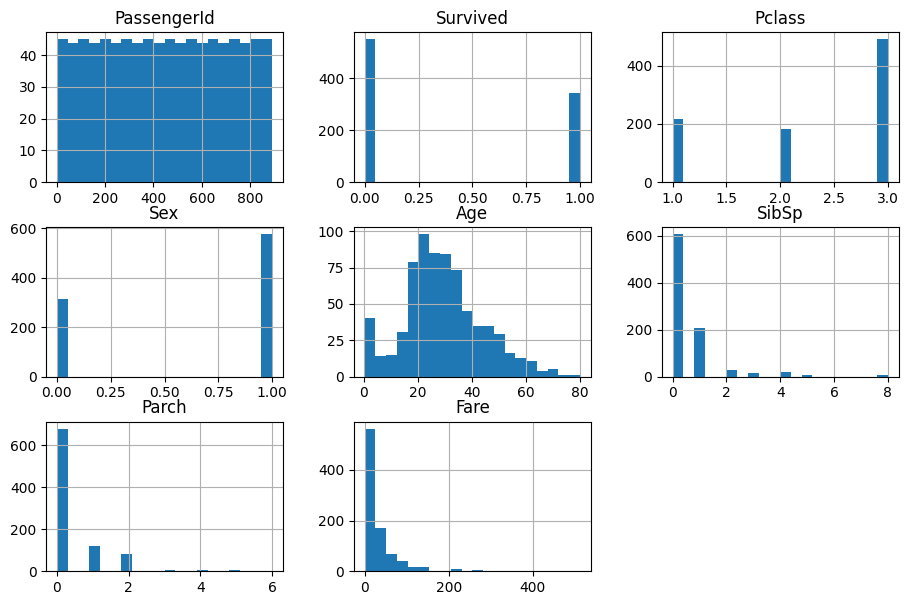

In [25]:
df.hist(figsize=(11,7) , bins=20)

# Some info

In [26]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,S


In [27]:
df.info()
# Delete PassengerId, Ticket, and Cabin. Then save the Tile of names(Mr, Miss , Ms ,...) and delete the rest.
# Use simple imputer for age and embarked.
# Use OneHotEncoder for Name(Title) , Sex , embarked.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    int64  
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(6), object(4)
memory usage: 83.7+ KB


# Correlation Heatmap

In [28]:
df_num = df.select_dtypes(include=['int64', 'float64'])
matrix_corr = df_num.corr()

'\nConvert Sex to num (0/1)\nPClass:\n    Being in a higher class(1st class) strongly increases survival chance and vice versa.\n    Paying a higher fare means higher survival probabilty.\n    Having parents/children aboard slightly increases survival (maybe parents fought to save their kids).\n    Action: Instead of using raw Age, bin it into categories (e.g., Child, Teen, Adult, Elder).\n    High correlation beteween features ==> Delete on of them. (In linear models , not needed in treebased models).\n    Create FamilySize feature ==> SibSp + Parch + 1 . Drop seperated columns.\n'

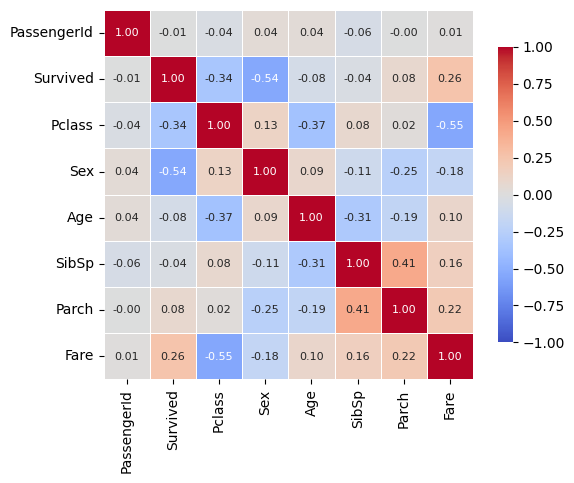

In [ ]:
sns.heatmap(
    matrix_corr,
    annot=True,           
    fmt='.2f',            
    cmap='coolwarm',      
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    vmin=-1, vmax=1,
    annot_kws={'size': 8}
)
"""
Convert Sex to num (0/1)
PClass:
    Being in a higher class(1st class) strongly increases survival chance and vice versa.
    Paying a higher fare means higher survival probabilty.
    Having parents/children aboard slightly increases survival (maybe parents fought to save their kids).
    Action: Instead of using raw Age, bin it into categories (e.g., Child, Teen, Adult, Elder).
    High correlation beteween features ==> Delete on of them. (In linear models , not needed in treebased models).
    Create FamilySize feature ==> SibSp + Parch + 1 . Drop seperated columns.
    As the number increases (towards male), survival decreases.
"""